In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('../data/da-loanDefaulter.csv')
print(df.head())

       LoanID       Name-Surname  Gender  Age  Income  LoanAmount  \
0  I38PQUQS96      Advik Maharaj    Male   56   85994       50587   
1  HPSK72WA7R        Isaac Dewan    Male   69   50432      124440   
2  C1OZ6DPJ8Y       Chameli Sami  Female   46   84208      129188   
3  V2KKSFM3UN  Alexander Chander    Male   32   31713       44799   
4  EY08JDHTZP     Jackson Tiwari    Male   60   20437        9139   

   CreditScore  MonthsEmployed  NumCreditLines  InterestRate  ...  \
0          520              80               4         15.23  ...   
1          458              15               1          4.81  ...   
2          451              26               3         21.17  ...   
3          743               0               3          7.07  ...   
4          633               8               4          6.51  ...   

   Low_Credit_Flag  Monthly_Income Estimated_EMI EMI_to_Income  \
0                1     7166.166667   1759.318045      0.245503   
1                1     4202.666667   2

In [12]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [13]:
df.shape

(255347, 35)

In [14]:
df.columns

Index(['LoanID', 'Name-Surname', 'Gender', 'Age', 'Income', 'LoanAmount',
       'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate',
       'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default',
       'Loan_to_Income', 'Credit_per_Line', 'Income_per_Employment',
       'Interest_Burden', 'High_DTI_Flag', 'Low_Credit_Flag', 'Monthly_Income',
       'Estimated_EMI', 'EMI_to_Income', 'Disposable_Income',
       'Income_After_EMI', 'CreditScore_Bucket', 'Income_Group',
       'Employment_Stability', 'Loan_Burden'],
      dtype='object')

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
for i in df.columns:
    print("Unique values in",i,":",df[i].nunique())

Unique values in LoanID : 255347
Unique values in Name-Surname : 255347
Unique values in Gender : 2
Unique values in Age : 52
Unique values in Income : 114620
Unique values in LoanAmount : 158729
Unique values in CreditScore : 550
Unique values in MonthsEmployed : 120
Unique values in NumCreditLines : 4
Unique values in InterestRate : 2301
Unique values in LoanTerm : 5
Unique values in DTIRatio : 81
Unique values in Education : 4
Unique values in EmploymentType : 4
Unique values in MaritalStatus : 3
Unique values in HasMortgage : 2
Unique values in HasDependents : 2
Unique values in LoanPurpose : 5
Unique values in HasCoSigner : 2
Unique values in Default : 2
Unique values in Loan_to_Income : 255330
Unique values in Credit_per_Line : 1796
Unique values in Income_per_Employment : 247165
Unique values in Interest_Burden : 7133
Unique values in High_DTI_Flag : 2
Unique values in Low_Credit_Flag : 2
Unique values in Monthly_Income : 114620
Unique values in Estimated_EMI : 255330
Unique val

## Identifier Analysis

Let's start with the boring-but-important housekeeping check: **are our IDs actually IDs?**

Good news — `LoanID` comes back with **255,347 unique values**, exactly matching our row count. Every single loan has its own fingerprint, no duplicates hiding anywhere, no two rows accidentally sharing an ID. That's confirmed independently by `df.duplicated().sum()` returning a clean **zero**. This dataset is duplicate-free at the record level, which means we can trust every row as an independent observation going forward.

`Name-Surname` tells the same story — 255,347 unique names, one per row. Since we generated these ourselves for the identity layer, this is expected rather than a discovery, but it's still worth confirming nothing collapsed or repeated during generation.

Here's the catch though: **neither of these columns should ever touch the model.** They're pure labels — a `LoanID` and a `Name-Surname` have no more relationship to someone's likelihood of defaulting than their shoe size does. If we let a tree-based model anywhere near a 255k-unique-value column, it *will* find "patterns" in it — except those patterns are just memorized noise, and the model will fall apart the moment it sees a new, unseen ID.

**The rule going forward:** these two columns live in the database and dashboard world, where a loan officer needs to see "Advik Maharaj — Loan #I38PQUQS96 — Risk: 0.73" on their screen. They have no business being inside `X_train`.


In [18]:
num_cols=[i for i in df.columns if df[i].dtype in ['int64','float64']]
cat_cols=[i for i in df.columns if df[i].dtype == 'object']

print("Numerical columns:",num_cols)
print("Categorical columns:",cat_cols)

Numerical columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default', 'Loan_to_Income', 'Credit_per_Line', 'Income_per_Employment', 'Interest_Burden', 'High_DTI_Flag', 'Low_Credit_Flag', 'Monthly_Income', 'Estimated_EMI', 'EMI_to_Income', 'Disposable_Income', 'Income_After_EMI', 'Employment_Stability', 'Loan_Burden']
Categorical columns: ['LoanID', 'Name-Surname', 'Gender', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'CreditScore_Bucket', 'Income_Group']


In [20]:
feature_groups = {
    "Identification": [
        "LoanID",
        "Name-Surname"
    ],

    "Demographic": [
        "Gender",
        "Age",
        "Education",
        "MaritalStatus",
        "HasDependents"
    ],

    "Financial": [
        "Income",
        "LoanAmount",
        "InterestRate",
        "DTIRatio",
        "Monthly_Income",
        "Disposable_Income",
        "Estimated_EMI",
        "EMI_to_Income",
        "Income_After_EMI",
        "Loan_Burden"
    ],

    "Credit History": [
        "CreditScore",
        "CreditScore_Bucket",
        "NumCreditLines",
        "Credit_per_Line",
        "Low_Credit_Flag"
    ],

    "Employment": [
        "EmploymentType",
        "MonthsEmployed",
        "Employment_Stability",
        "Income_per_Employment"
    ],

    "Loan Information": [
        "LoanPurpose",
        "LoanTerm",
        "HasMortgage",
        "HasCoSigner"
    ],

    "Engineered Features": [
        "Loan_to_Income",
        "Interest_Burden",
        "High_DTI_Flag",
    ],

    "Target": [
        "Default"
    ]
}


In [22]:
# for invalidd values
print("Age less than 18 :", (df["Age"] < 18).sum())

print("Income <= 0 :", (df["Income"] <= 0).sum())

print("Loan Amount <= 0 :", (df["LoanAmount"] <= 0).sum())

print("Credit Score <= 0 :", (df["CreditScore"] <= 0).sum())

print("Interest Rate <= 0 :", (df["InterestRate"] <= 0).sum())

print("Loan Term <= 0 :", (df["LoanTerm"] <= 0).sum())

print("DTI Ratio < 0 :", (df["DTIRatio"] < 0).sum())

print("Months Employed < 0 :", (df["MonthsEmployed"] < 0).sum())

Age less than 18 : 0
Income <= 0 : 0
Loan Amount <= 0 : 0
Credit Score <= 0 : 0
Interest Rate <= 0 : 0
Loan Term <= 0 : 0
DTI Ratio < 0 : 0
Months Employed < 0 : 0


In [ ]:
identifier_features = [
    "LoanID",
    "Name-Surname"
]

categorical_features = [
    "Gender",
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner",
    "CreditScore_Bucket",
    "Income_Group"
]

binary_numeric_features = [
    "High_DTI_Flag",
    "Low_Credit_Flag"
]

numerical_features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
    "Loan_to_Income",
    "Credit_per_Line",
    "Income_per_Employment",
    "Interest_Burden",
    "Monthly_Income",
    "Estimated_EMI",
    "EMI_to_Income",
    "Disposable_Income",
    "Income_After_EMI",
    "Employment_Stability",
    "Loan_Burden"
]

GENDER


Gender
Female    129975
Male      125372
Name: count, dtype: int64

Gender
Female    50.9
Male      49.1
Name: proportion, dtype: float64

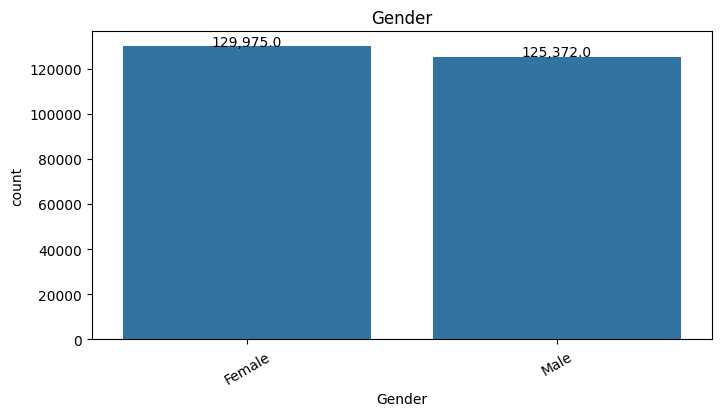

EDUCATION


Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

Education
Bachelor's     25.21
High School    25.03
Master's       24.88
PhD            24.88
Name: proportion, dtype: float64

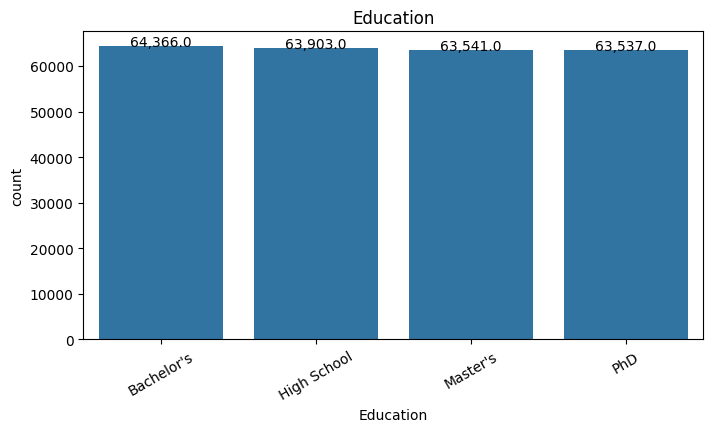

EMPLOYMENTTYPE


EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

EmploymentType
Part-time        25.13
Unemployed       25.00
Self-employed    24.95
Full-time        24.93
Name: proportion, dtype: float64

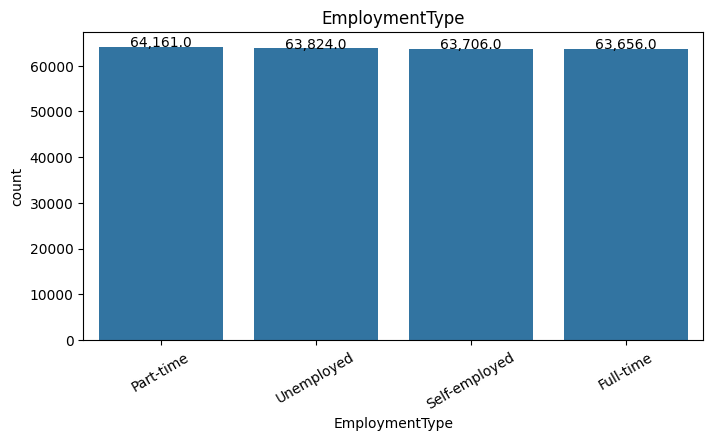

MARITALSTATUS


MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

MaritalStatus
Married     33.41
Divorced    33.30
Single      33.29
Name: proportion, dtype: float64

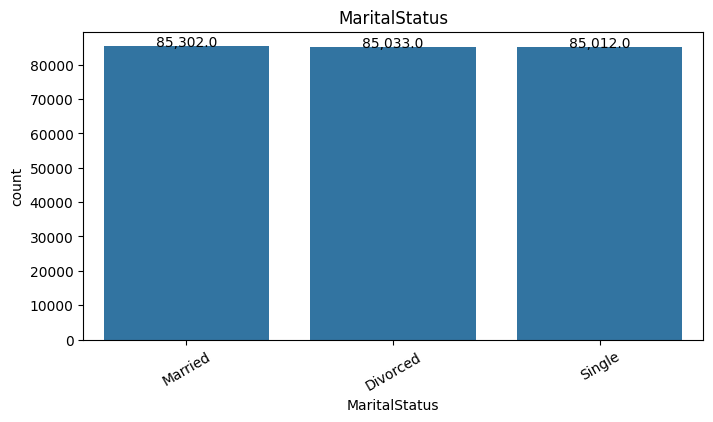

HASMORTGAGE


HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

HasMortgage
Yes    50.0
No     50.0
Name: proportion, dtype: float64

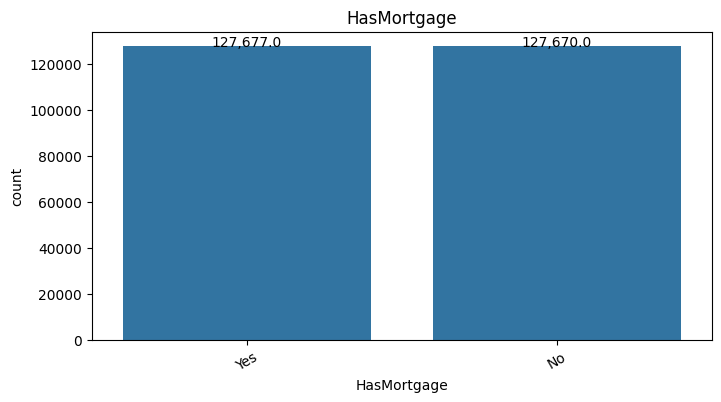

HASDEPENDENTS


HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

HasDependents
Yes    50.03
No     49.97
Name: proportion, dtype: float64

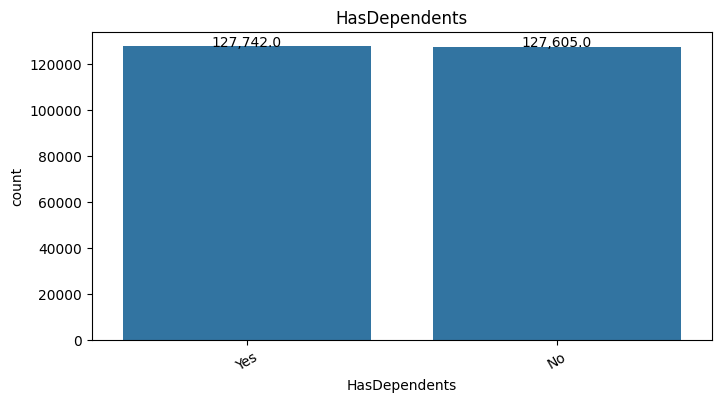

LOANPURPOSE


LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

LoanPurpose
Business     20.09
Home         20.08
Education    19.97
Other        19.94
Auto         19.91
Name: proportion, dtype: float64

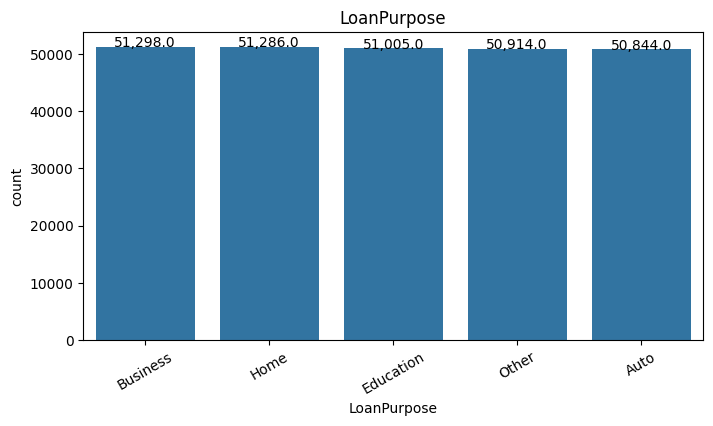

HASCOSIGNER


HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64

HasCoSigner
Yes    50.01
No     49.99
Name: proportion, dtype: float64

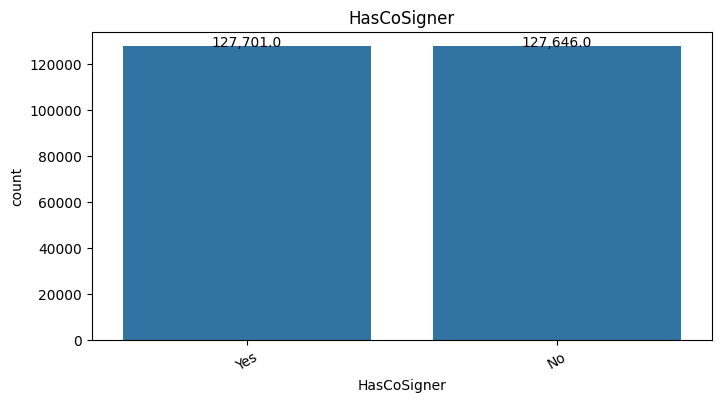

CREDITSCORE_BUCKET


CreditScore_Bucket
Poor         130708
Fair          41877
Good          31991
Very Good     27771
Excellent     23000
Name: count, dtype: int64

CreditScore_Bucket
Poor         51.19
Fair         16.40
Good         12.53
Very Good    10.88
Excellent     9.01
Name: proportion, dtype: float64

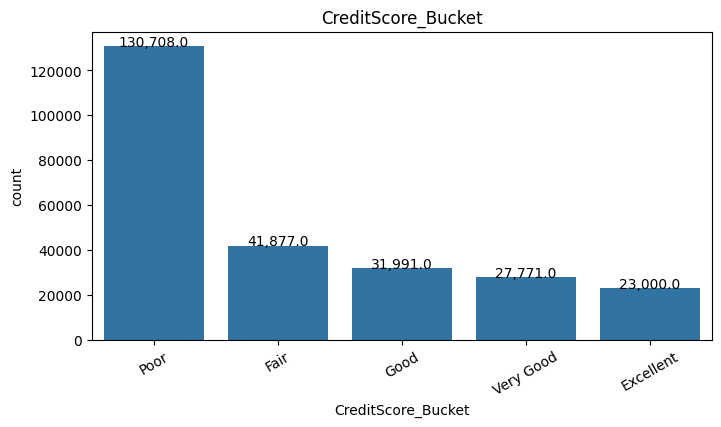

INCOME_GROUP


Income_Group
High         63839
Medium       63837
Low          63837
Very High    63834
Name: count, dtype: int64

Income_Group
High         25.0
Medium       25.0
Low          25.0
Very High    25.0
Name: proportion, dtype: float64

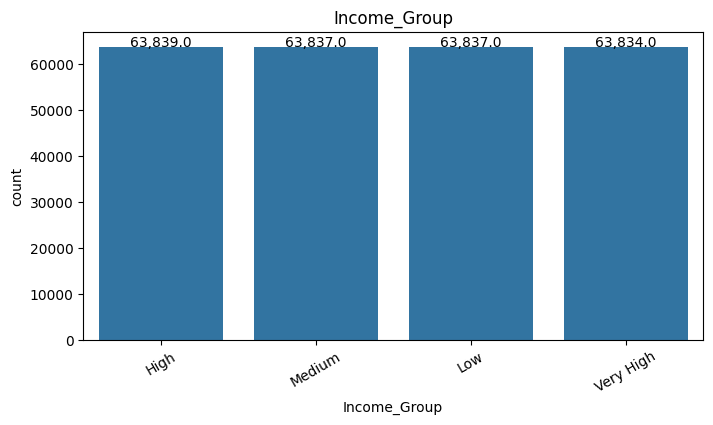

In [ ]:
def analyze_categorical(df, column):

    print("="*90)
    print(column.upper())
    print("="*90)

    display(df[column].value_counts())

    display(round(df[column].value_counts(normalize=True)*100,2))

    plt.figure(figsize=(8,4))

    ax = sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():,}',
            (p.get_x()+p.get_width()/2,
             p.get_height()),
            ha='center',
            fontsize=10
        )

    plt.xticks(rotation=30)

    plt.title(column)

    plt.show()


for col in categorical_features:
    analyze_categorical(df,col)

## Categorical Feature Analysis

Here's where the dataset starts revealing its personality — and honestly, its biggest tell that it's synthetic.

Walk through `Gender`, `Education`, `EmploymentType`, `MaritalStatus`, `HasMortgage`, `HasDependents`, `LoanPurpose`, and `HasCoSigner`, and you'll notice something almost eerie: **every single one of them splits almost perfectly evenly** across its categories. Gender sits at a near-coin-flip 50.9% Female to 49.1% Male. Education spreads its four categories within half a percentage point of 25% each. Marital status, employment type, loan purpose — same story, every time, suspiciously balanced. Real-world credit populations are never this tidy. People don't distribute themselves evenly across "Bachelor's, Master's, PhD, and High School" in real life — this is the fingerprint of a dataset built from a random generator rather than sampled from actual humans.

Then there's the one column that breaks the pattern entirely: **`CreditScore_Bucket`.** Instead of a clean even split, over half the portfolio — **51.2%** — lands in the "Poor" bucket, tapering down through Fair (16.4%), Good (12.5%), Very Good (10.9%), all the way to a mere 9% in "Excellent." This is the first real signal we've found in the categorical space. It tells us the raw `CreditScore` column underneath isn't uniform at all — it's skewed toward the lower end — which makes both `CreditScore` and its bucketed version strong early candidates for your most predictive features.

`Income_Group` looks perfectly uniform too, but don't read too much into that — it's quartile-binned by construction, so of course each group holds exactly 25%. That flat distribution isn't telling us anything about risk; the real story will only show up once we check the *default rate* inside each bucket, not the population share.

**The takeaway to carry forward:** a uniform *distribution* doesn't mean a feature is useless — it just means the input side looks balanced. The real test is whether the *default rate* shifts once you slice by category. That's the crosstab worth running next: `pd.crosstab(df['CreditScore_Bucket'], df['Default'], normalize='index')` — and I'd bet money that's where the real differentiation lives.


HIGH_DTI_FLAG


High_DTI_Flag
1    157978
0     97369
Name: count, dtype: int64

High_DTI_Flag
1    61.87
0    38.13
Name: proportion, dtype: float64

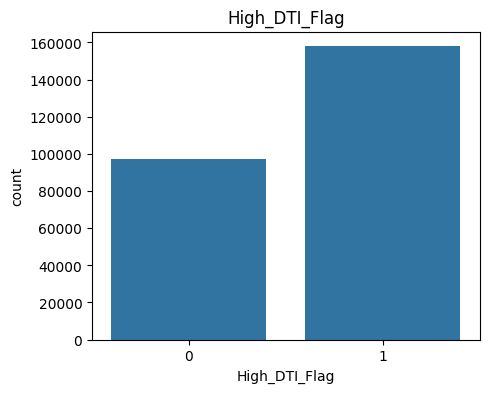

LOW_CREDIT_FLAG


Low_Credit_Flag
1    139483
0    115864
Name: count, dtype: int64

Low_Credit_Flag
1    54.62
0    45.38
Name: proportion, dtype: float64

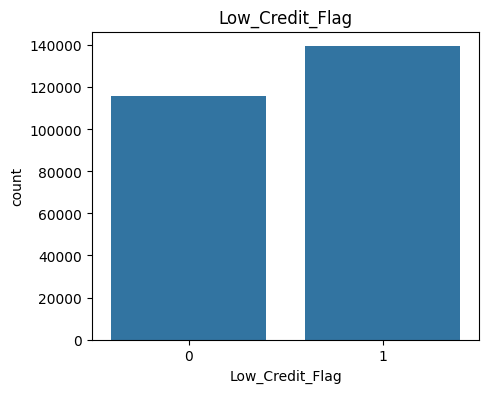

In [28]:
def analyze_binary(df,column):

    print("="*90)
    print(column.upper())
    print("="*90)

    display(df[column].value_counts())

    display(round(df[column].value_counts(normalize=True)*100,2))

    plt.figure(figsize=(5,4))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(column)

    plt.show()


for col in binary_numeric_features:
    analyze_binary(df,col)

##  Binary Feature Analysis

Two flags, two very different vibes from everything we just looked at.

Where `HasMortgage`, `HasCoSigner`, and friends all sat at a comfortable 50/50, our engineered risk flags tell a different story. **`High_DTI_Flag` fires for 61.9% of the entire portfolio** — meaning nearly two out of every three borrowers are already sitting in the "high debt-to-income" bucket. `Low_Credit_Flag` isn't far behind at **54.6%**. Unlike the raw categorical columns, these weren't built to land evenly — they're reflecting something real (or realistically synthesized) about the underlying `DTIRatio` and `CreditScore` distributions.

Here's the part that should make you pause: if 62% of people are flagged high-risk on DTI and 55% are flagged low-credit, but only **~11.6%** of the whole dataset actually defaults — where did everyone else go? Clearly, being flagged "risky" on a single dimension isn't a death sentence in this data. Most flagged borrowers still pay their loans back just fine. That's actually a really useful discovery: it tells us **no single flag is doing the heavy lifting alone**. The real risk signal is probably hiding in the *combinations* — someone who's high-DTI *and* low-credit *and* has a negative `Income_After_EMI` is a completely different story than someone who just trips one flag in isolation.

Worth a gut-check too: these flags are literally derived from `DTIRatio` and `CreditScore`, which we're also keeping as raw features. That's not a dealbreaker for tree-based models — they shrug off redundant features — but if logistic regression is on your roadmap, keep an eye on multicollinearity here.

**Next move:** run `df.groupby('High_DTI_Flag')['Default'].mean()` (and the same for `Low_Credit_Flag`) to put an actual number on how much each flag shifts the odds of default. That's the number that tells you whether these flags are pulling their weight.


In [29]:
# Demographics
demographic_num = [
    "Age"
]

# Financial
financial_num = [
    "Income",
    "LoanAmount",
    "InterestRate",
    "DTIRatio",
    "Monthly_Income",
    "Estimated_EMI",
    "EMI_to_Income",
    "Disposable_Income",
    "Income_After_EMI",
    "Loan_Burden"
]

# Credit
credit_num = [
    "CreditScore",
    "NumCreditLines",
    "Credit_per_Line",
    "Loan_to_Income"
]

# Employment
employment_num = [
    "MonthsEmployed",
    "Income_per_Employment",
    "Employment_Stability"
]

# Engineered Risk
risk_num = [
    "Interest_Burden"
]

INCOME
count    255347.000000
mean      82499.304597
std       38963.013729
min       15000.000000
25%       48825.500000
50%       82466.000000
75%      116219.000000
max      149999.000000
Name: Income, dtype: float64

Missing Values : 0
Unique Values  : 114620
Skewness       : -0.0
Kurtosis       : -1.198


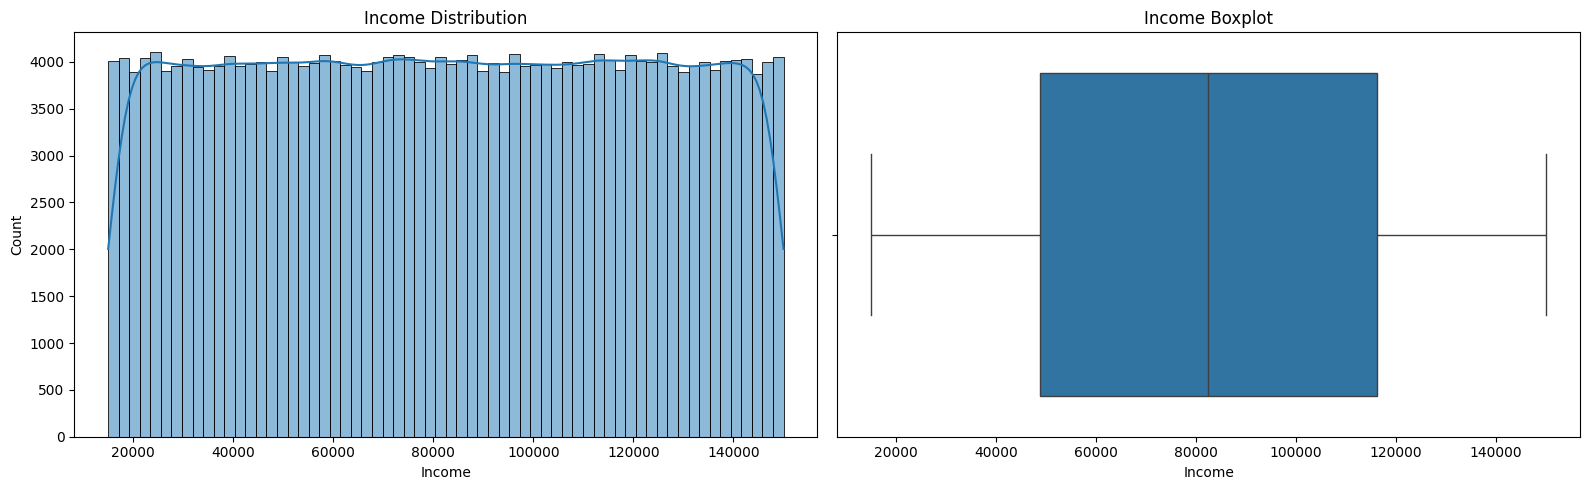

LOANAMOUNT
count    255347.000000
mean     127578.865512
std       70840.706142
min        5000.000000
25%       66156.000000
50%      127556.000000
75%      188985.000000
max      249999.000000
Name: LoanAmount, dtype: float64

Missing Values : 0
Unique Values  : 158729
Skewness       : -0.002
Kurtosis       : -1.204


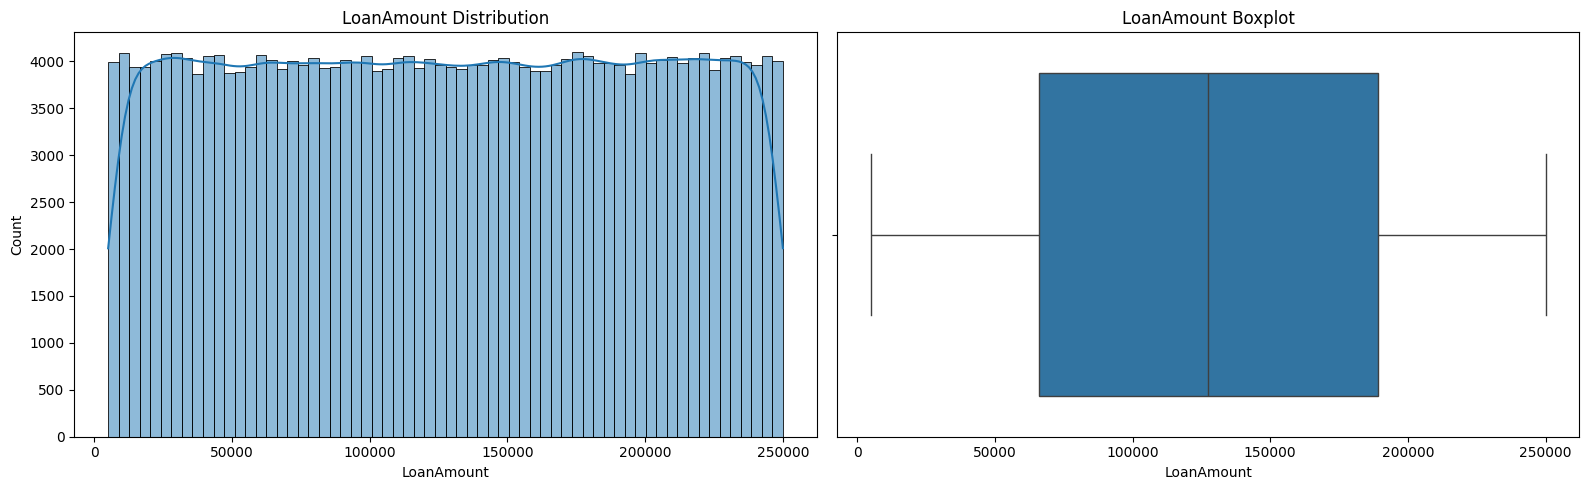

INTERESTRATE
count    255347.000000
mean         13.492773
std           6.636443
min           2.000000
25%           7.770000
50%          13.460000
75%          19.250000
max          25.000000
Name: InterestRate, dtype: float64

Missing Values : 0
Unique Values  : 2301
Skewness       : 0.005
Kurtosis       : -1.197


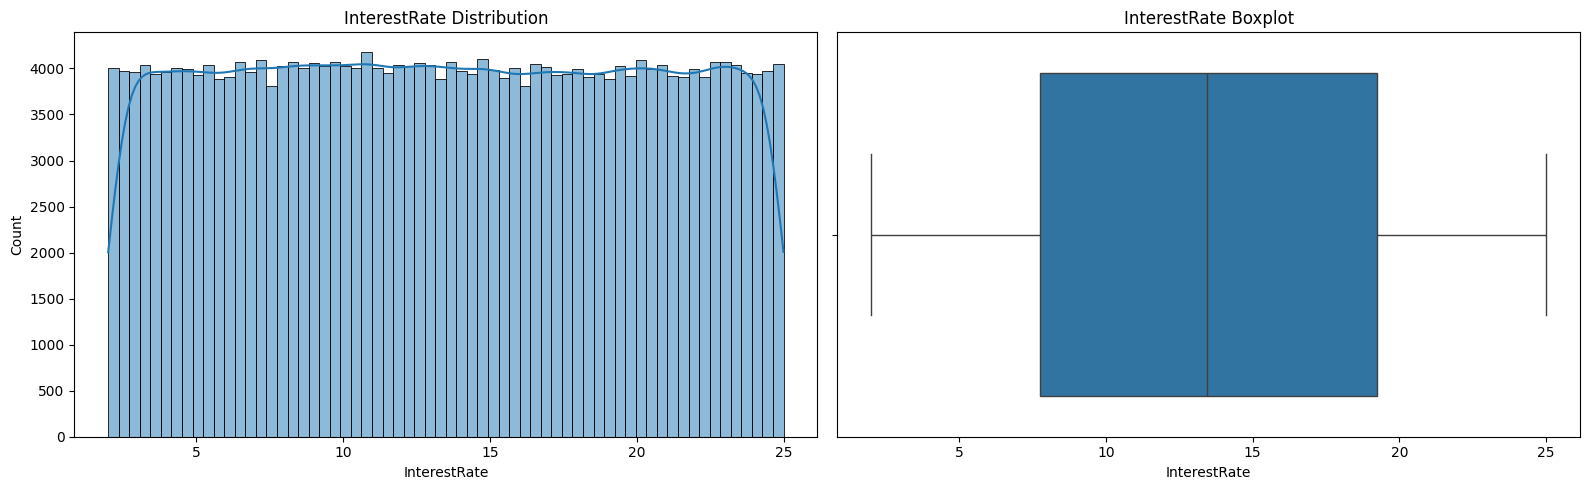

DTIRATIO
count    255347.000000
mean          0.500212
std           0.230917
min           0.100000
25%           0.300000
50%           0.500000
75%           0.700000
max           0.900000
Name: DTIRatio, dtype: float64

Missing Values : 0
Unique Values  : 81
Skewness       : -0.001
Kurtosis       : -1.2


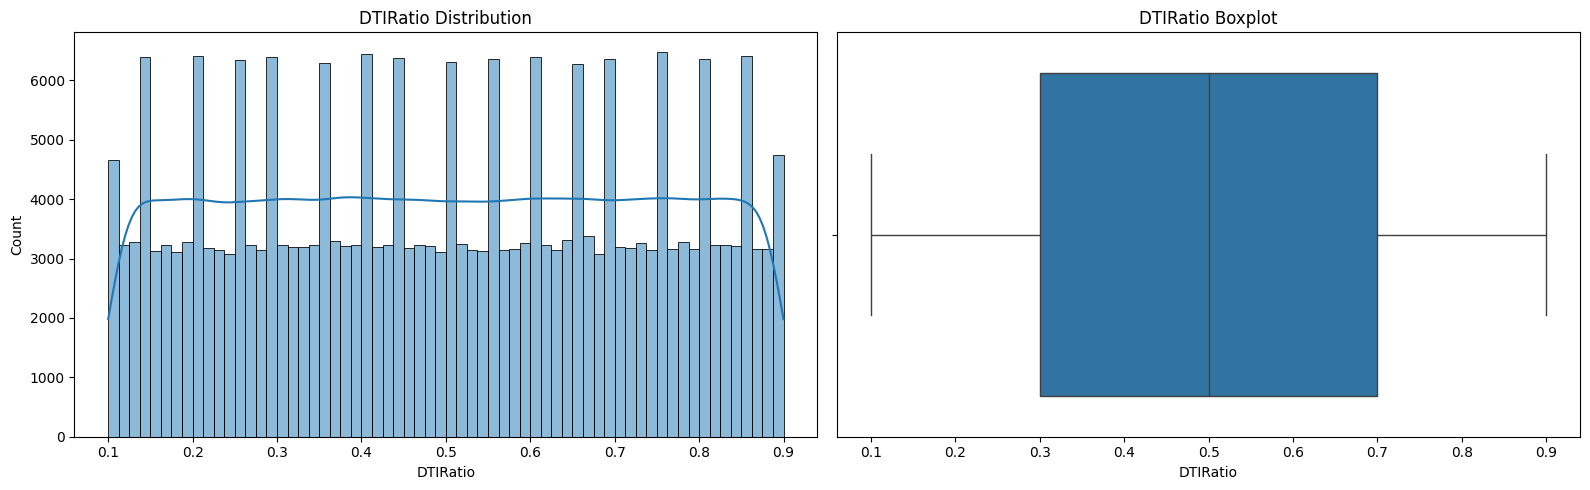

MONTHLY_INCOME
count    255347.000000
mean       6874.942050
std        3246.917811
min        1250.000000
25%        4068.791667
50%        6872.166667
75%        9684.916667
max       12499.916667
Name: Monthly_Income, dtype: float64

Missing Values : 0
Unique Values  : 114620
Skewness       : -0.0
Kurtosis       : -1.198


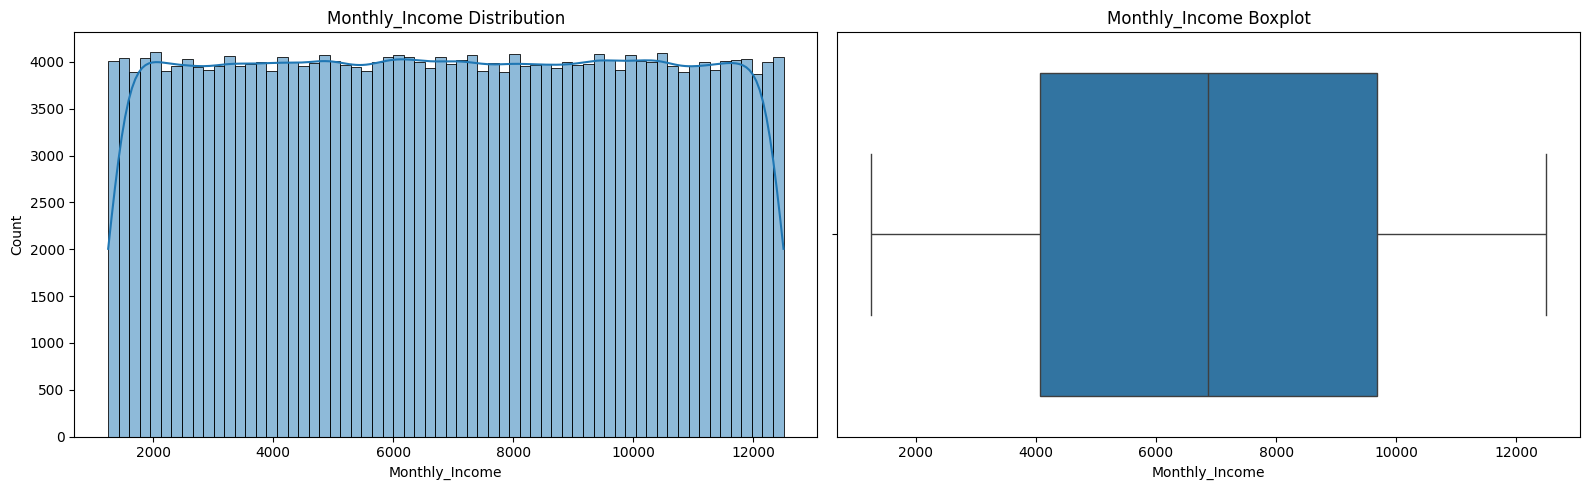

ESTIMATED_EMI
count    255347.000000
mean       5649.062363
std        4731.401956
min          90.802843
25%        2317.463583
50%        4442.059863
75%        7259.845864
max       23735.666660
Name: Estimated_EMI, dtype: float64

Missing Values : 0
Unique Values  : 255330
Skewness       : 1.523
Kurtosis       : 2.149


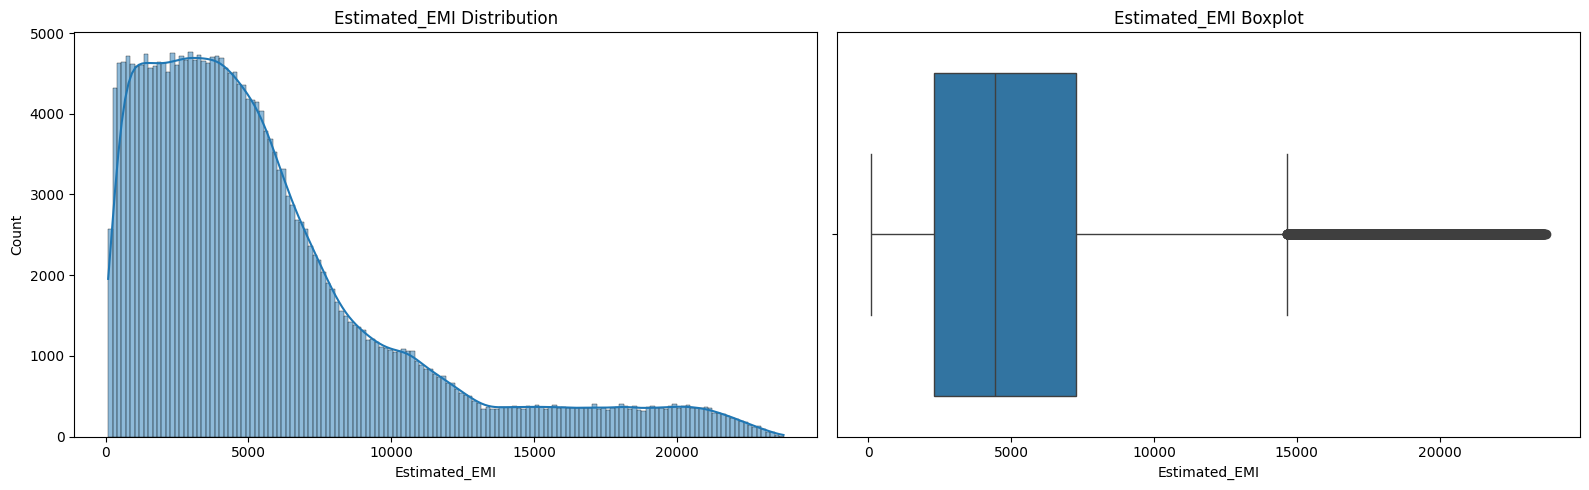

EMI_TO_INCOME
count    255347.000000
mean          1.157286
std           1.466405
min           0.008192
25%           0.336087
50%           0.682542
75%           1.397868
max          18.086068
Name: EMI_to_Income, dtype: float64

Missing Values : 0
Unique Values  : 255347
Skewness       : 3.635
Kurtosis       : 19.666


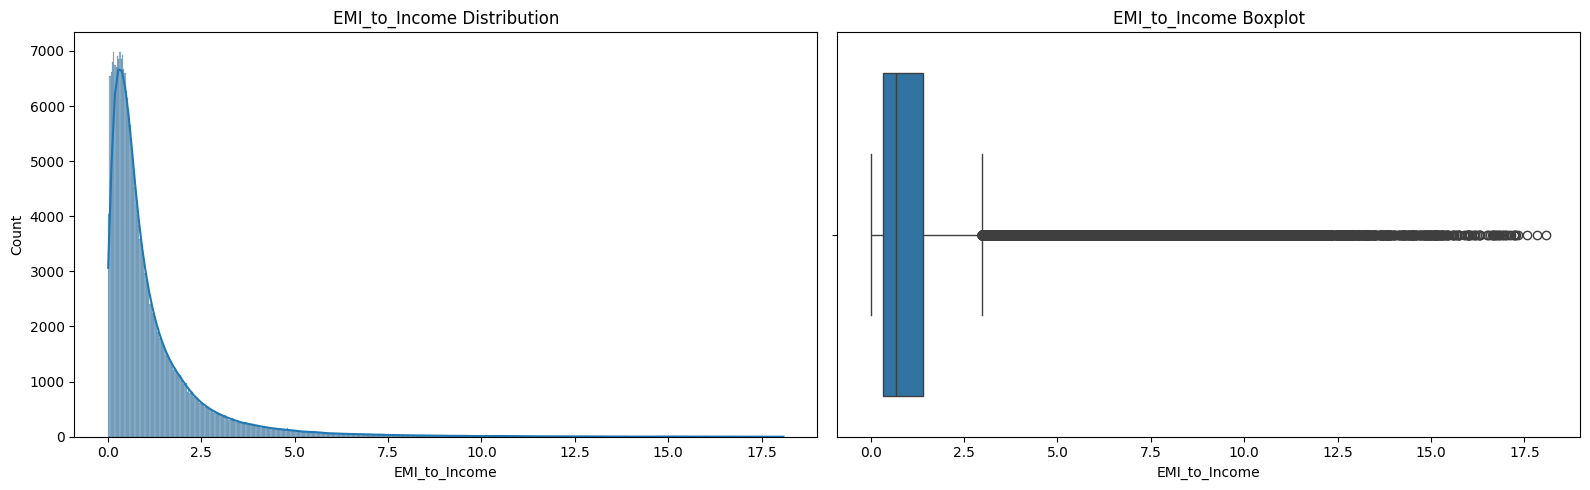

DISPOSABLE_INCOME
count    255347.000000
mean      41230.308247
std       28698.244967
min        1509.700000
25%       17824.405000
50%       34053.600000
75%       59109.355000
max      134964.900000
Name: Disposable_Income, dtype: float64

Missing Values : 0
Unique Values  : 246933
Skewness       : 0.851
Kurtosis       : -0.055


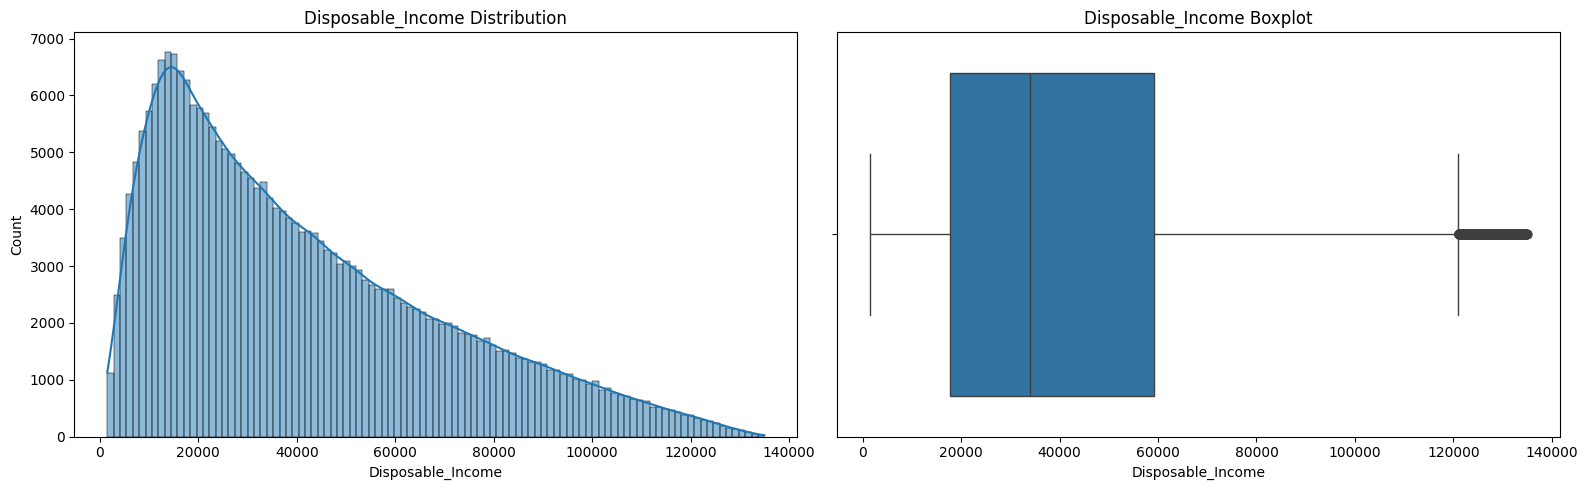

INCOME_AFTER_EMI
count    255347.000000
mean       1225.879687
std        5742.986771
min      -21804.859765
25%       -1753.536395
50%        1881.075255
75%        5315.675007
max       12357.739651
Name: Income_After_EMI, dtype: float64

Missing Values : 0
Unique Values  : 255347
Skewness       : -0.857
Kurtosis       : 0.879


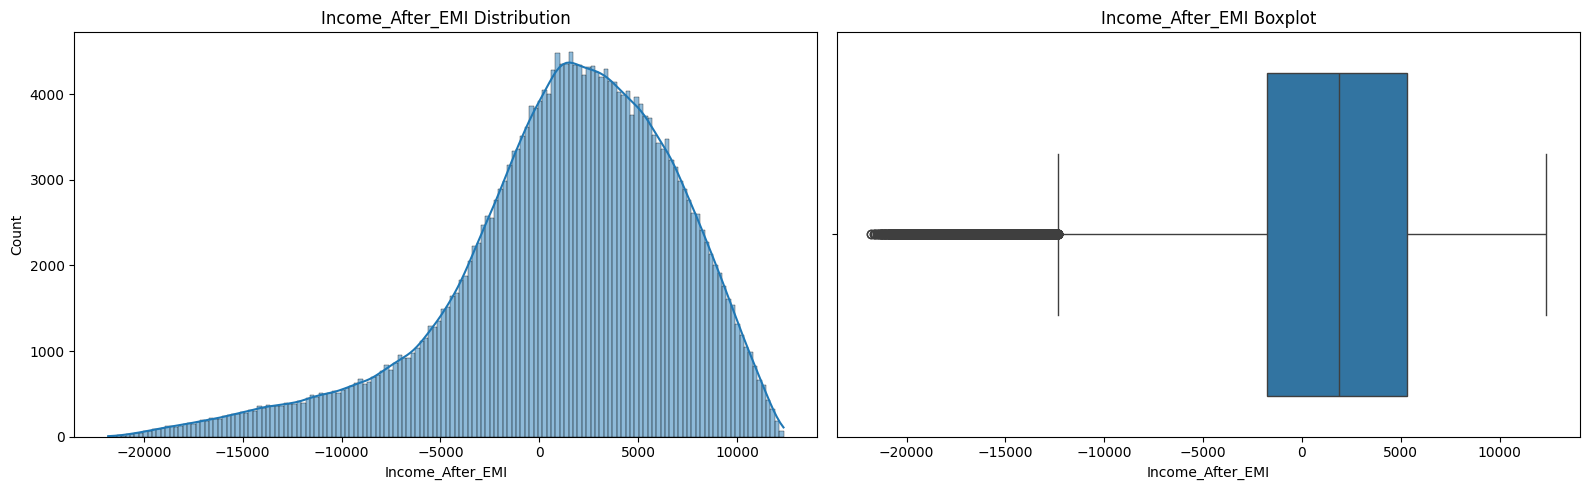

LOAN_BURDEN
count    255347.000000
mean          1.089513
std           1.300714
min           0.004184
25%           0.298025
50%           0.676780
75%           1.348383
max          13.959855
Name: Loan_Burden, dtype: float64

Missing Values : 0
Unique Values  : 255343
Skewness       : 2.993
Kurtosis       : 12.606


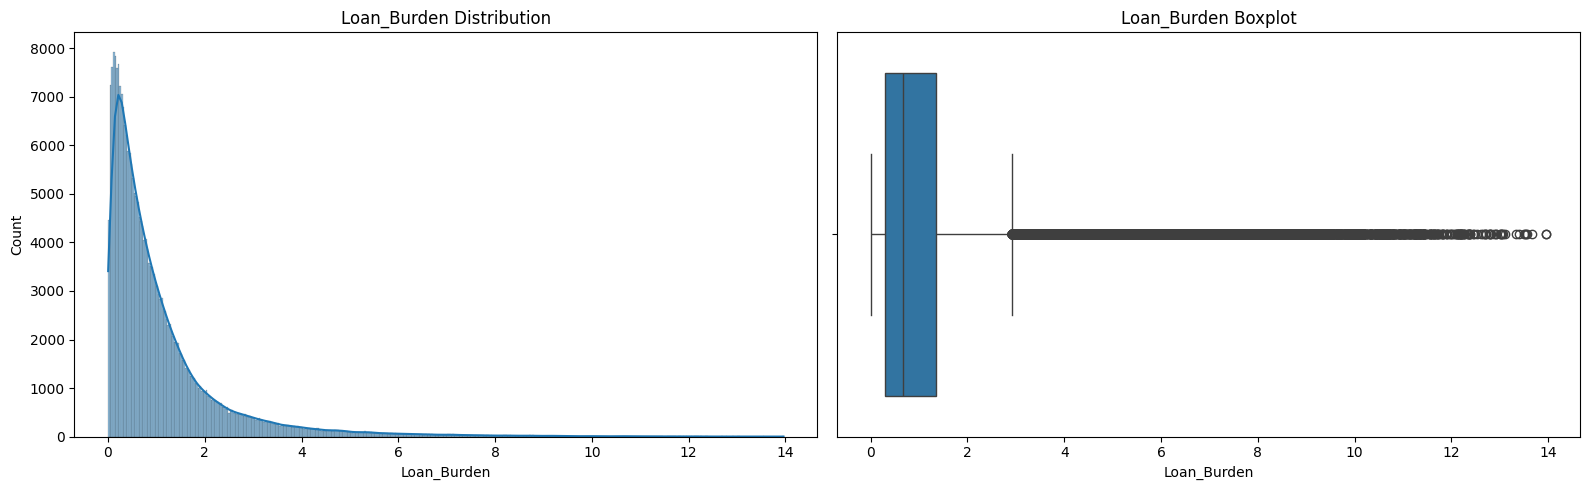

In [30]:
for col in financial_num:
    analyze_numeric(df, col)

## Numerical Feature Analysis

This is where the dataset gets genuinely interesting — and where one number should stop you in your tracks.

Quick flag before we dive in: the notebook set up four numeric groups to explore — `demographic_num`, `credit_num`, `employment_num`, and `risk_num` — but only `financial_num` actually got run through `analyze_numeric()`. That means `Age`, `CreditScore`, `NumCreditLines`, `MonthsEmployed`, and a few others are still sitting unexamined. Given that `CreditScore` and `Age` are usually the backbone of any credit risk model, that's a gap worth closing before you move on — consider this your to-do, not a finished checklist.

Now, onto what we *did* find. The four raw financial inputs — `Income`, `LoanAmount`, `InterestRate`, and `DTIRatio` — all share the same personality: **flat, symmetric, almost perfectly uniform**, with skewness hovering right around zero and kurtosis consistently around -1.2. Income ranges cleanly from 15k to 150k, loan amounts from 5k to 250k, interest rates from 2% to 25% — all spread evenly across their ranges rather than clustering realistically the way real-world income or loan data usually does (which tends to pile up on one side with a long tail). Another strong hint we're working with generated data rather than a live population — and a useful thing to know, because it means these raw features may carry less natural non-linear signal than you'd expect from real bureau data.

The engineered EMI-related features are a completely different animal. `Estimated_EMI` leans right with a skew of **1.52**, but `EMI_to_Income` takes it to another level entirely — a skew of **3.64** and a kurtosis of **19.67**, with values stretching all the way up to a borrower paying roughly **18 times** their monthly income in EMI. That's not a typo, that's an extreme tail worth capping or investigating before it distorts a linear model. `Loan_Burden` tells a nearly identical story, skewing at **2.99** with a similarly heavy tail.

But here's the number that should really grab your attention: **`Income_After_EMI` dips as low as -21,805.** Read that again — a meaningful chunk of this portfolio has *negative* income left over after paying their estimated EMI. In plain English: they can't actually afford their own loan payment from their income alone. If there's one feature in this entire dataset I'd bet is doing the heaviest lifting for predicting `Default`, it's this one. Before you build a single model, run the simplest possible check — compare the default rate for everyone with `Income_After_EMI < 0` against everyone at or above zero. I'd be surprised if that split isn't dramatic.

**Bottom line:** the raw inputs look artificially tame, but the engineered affordability features — especially `Income_After_EMI` and `EMI_to_Income` — are where the real risk story is being told. Finish profiling `Age` and `CreditScore` next, then go straight to that negative-income cross-check. That's your highest-value next step in this whole EDA.
